In [1]:
import numpy as np
import pandas as pd
import re

In [5]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
df=pd.read_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data.csv')
df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,pioneer park,sector 61,1.60,11594.0,1380.0,Carpet area: 1380 (128.21 sq.m.),2,2,2,servant room,21.0,NaN,1 to 5 Year Old,"['Sector 55-56 Rapid Metro', 'Hong Kong Bazaar...","['2 Wardrobe', 'No AC', 'No Bed', 'No Chimney'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1,flat,godrej nature plus,sector 33,1.15,11558.0,995.0,Carpet area: 92.44,2,2,2,na,15.0,NaN,Dec 2023,"['Signature Global Infinity Mall Sohna', 'Bads...","['3 Fan', '1 Exhaust Fan', '5 Light', 'No AC',...","['Intercom Facility', 'Lift(s)', 'Swimming Poo..."
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.),5,5,3,na,2.0,NaN,1 to 5 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...","['5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Micr...","['Private Garden / Terrace', 'Maintenance Staf..."
3,flat,bptp astaire gardens,sector 70a,1.60,8658.0,1848.0,Super Built up area 1848(171.68 sq.m.)Built Up...,4,4,3,"study room,others",1.0,NaN,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall'...","['1 Fan', '1 Light', '2 Chimney', '4 AC', 'No ...","['Feng Shui / Vaastu Compliant', 'Security / F..."
4,flat,ats triumph,sector 104,1.75,7641.0,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,"pooja room,study room,servant room,others",12.0,North-West,1 to 5 Year Old,"['IFFCO Chowk Metro Station', 'The Esplanade M...","['4 Wardrobe', '7 Fan', '19 Light', '1 Chimney...","['Intercom Facility', 'Lift(s)', 'Maintenance ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3798,flat,shree vardhman victoria,sector 70,1.60,8205.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,servant room,6.0,North,1 to 5 Year Old,"['Airia Mall', 'Golf Course Extn Road', 'Sohna...","['3 Wardrobe', '1 Modular Kitchen', 'No AC', '...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."
3799,flat,m3m heights,sector 65,1.99,15793.0,1260.0,Super Built up area 1260(117.06 sq.m.),2,2,2,na,26.0,NaN,Dec 2023,"['Rapid Metro Sector 56', 'M3m 65th Avenue Mal...",[],NaN
3800,flat,smart world orchard,sector 61,1.60,13913.0,1150.0,Carpet area: 1150 (106.84 sq.m.),2,2,2,na,4.0,NaN,Under Construction,"['Sector 55-56 Metro station', 'Bestech Centra...",[],"['Lift(s)', 'Swimming Pool', 'Fitness Centre /..."
3801,flat,sare crescent parc,sector 92,0.90,4278.0,2104.0,Super Built up area 1870(173.73 sq.m.),4,5,3+,"servant room,others",14.0,North-East,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",[],"['Security / Fire Alarm', 'Lift(s)', 'Maintena..."


## areaWithType

In [6]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1454,1.20,1492.0,Built Up area: 1492 (138.61 sq.m.)Carpet area: 900 sq.ft. (83.61 sq.m.)
1498,2.45,2450.0,Super Built up area 2450(227.61 sq.m.)Carpet area: 1840 sq.ft. (170.94 sq.m.)
1137,1.00,1100.0,Super Built up area 1100(102.19 sq.m.)
1725,3.00,1667.0,Super Built up area 1828(169.83 sq.m.)
1729,1.30,1818.0,Super Built up area 1818(168.9 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.)


In [7]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [10]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [11]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3138,2.15,flat,5201.0,Super Built up area 5200(483.1 sq.m.)Built Up area: 4600 sq.ft. (427.35 sq.m.)Carpet area: 4000 sq.ft. (371.61 sq.m.),5200.0,4600.0,4000.0
3469,3.50,house,3800.0,Built Up area: 3800 (353.03 sq.m.),NaN,3800.0,NaN
1408,1.70,flat,1570.0,Built Up area: 1570 (145.86 sq.m.)Carpet area: 1099 sq.ft. (102.1 sq.m.),NaN,1570.0,1099.0
2790,0.47,house,1336.0,Built Up area: 1350 (125.42 sq.m.),NaN,1350.0,NaN
2309,4.25,flat,3763.0,Super Built up area 3763(349.59 sq.m.)Built Up area: 3000 sq.ft. (278.71 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.),3763.0,3000.0,2800.0


In [15]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [17]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
5,9.50,house,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 sq.yards (250.84 sq.m.)Carpet area: 250 sq.yards (209.03 sq.m.),NaN,300.0,250.0
6,4.60,house,1460.0,Plot area 1460(135.64 sq.m.),NaN,NaN,NaN
7,5.46,house,2259.0,Plot area 251(209.87 sq.m.),NaN,NaN,NaN
9,14.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN


In [18]:

df.isnull().sum()

property_type             0
society                 487
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [19]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [20]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [21]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [22]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
6,4.60,house,1460.0,Plot area 1460(135.64 sq.m.),NaN,1460.00,NaN
7,5.46,house,2259.0,Plot area 251(209.87 sq.m.),NaN,251.00,NaN
9,14.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.00,NaN
19,0.66,house,550.0,Plot area 550(51.1 sq.m.),NaN,550.00,NaN
22,12.50,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
28,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
34,2.50,house,1900.0,Plot area 1900(176.52 sq.m.),NaN,1900.00,NaN
35,4.50,house,4950.0,Plot area 550(459.87 sq.m.),NaN,550.00,NaN
38,7.00,house,5400.0,Plot area 600(501.68 sq.m.),NaN,600.00,NaN


In [23]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [24]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [25]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
6,4.60,house,1460.0,Plot area 1460(135.64 sq.m.),NaN,1460.00,NaN
7,5.46,house,2259.0,Plot area 251(209.87 sq.m.),NaN,2259.00,NaN
9,14.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,2844.00,NaN
19,0.66,house,550.0,Plot area 550(51.1 sq.m.),NaN,550.00,NaN
22,12.50,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
28,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
34,2.50,house,1900.0,Plot area 1900(176.52 sq.m.),NaN,1900.00,NaN
35,4.50,house,4950.0,Plot area 550(459.87 sq.m.),NaN,4950.00,NaN
38,7.00,house,5400.0,Plot area 600(501.68 sq.m.),NaN,5400.00,NaN


In [26]:
# update the original dataframe
df.update(all_nan_df)

In [27]:
df.isnull().sum()

property_type             0
society                 487
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

## additionalRoom

In [28]:
df['additionalRoom'].value_counts()

additionalRoom
na                                               1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [ ]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [31]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
847,na,0,0,0,0,0
3281,na,0,0,0,0,0
2644,others,0,0,0,0,1
967,"servant room,study room,pooja room,store room",1,1,1,1,0
2356,na,0,0,0,0,0


## agePossession

In [32]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Jun 2024                 7
Aug 2023                 7
Dec 2025                 7
Nov 2023                 5
Oct 2023                 4
Aug 2024                 4
By 2025                  4
Jul 2024                 4
Sep 2023                 4
May 2024                 3
Feb 2024                 3
Nov 2024                 3
Jan 2025                 3
Jul 2027                 2
Oct 2025                 2
Jan 2026                 2
Aug 2025                 2
Dec 2026                 2
Jul 2025                 2
Jun 2027                 2
Apr 2026                 2
Mar 2025      

In [33]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [34]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [35]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

## furnishDetails

In [36]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3054,NaN,NaN
2503,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
422,"['4 Wardrobe', '1 Water Purifier', '7 Fan', '1 Exhaust Fan', '5 Geyser', '25 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3367,"['1 Water Purifier', '5 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '4 Geyser', '1 Stove', '12 Light', '4 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 Bed', '4 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"
785,[],"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [37]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings
 
# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\msi 1\AppData\Local\Temp\ipykernel_18540\2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [39]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

In [40]:
furnishings_df.sample(5)

,Exhaust Fan,Bed,TV,Water Purifier,Sofa,Light,Wardrobe,Microwave,Dining Table,Geyser,Curtains,Modular Kitchen,Stove,AC,Chimney,Fan,Washing Machine,Fridge
2891,1,0,0,0,0,11,3,0,0,3,0,1,0,3,1,9,0,0
500,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
982,1,0,0,0,0,7,3,0,0,0,1,1,0,0,0,5,0,0
3077,0,0,0,0,0,1,1,0,0,1,0,0,0,1,1,1,0,0
2315,1,0,0,0,0,5,3,0,0,0,0,1,0,5,1,5,0,0


In [41]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [43]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

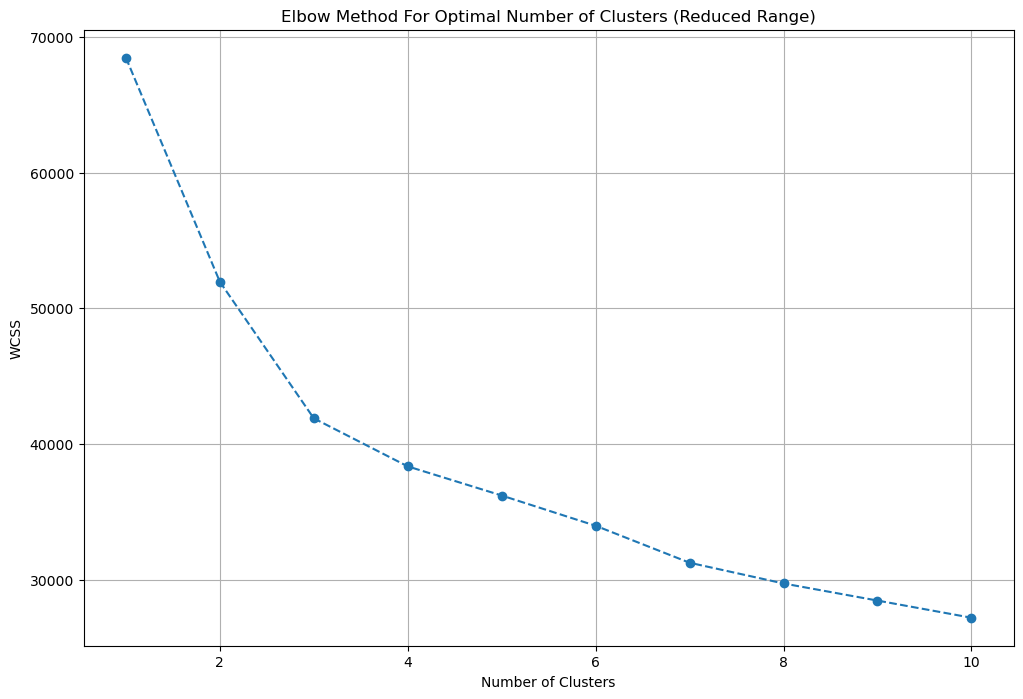

In [44]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [45]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [ ]:
df = df.iloc[:,:-18]

In [49]:
df['furnishing_type'] = cluster_assignments

In [50]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
543,"['1 Water Purifier', '3 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '3 Geyser', '1 Stove', '4 Light', '3 AC', '2 TV', '1 Modular Kitchen', '1 Chimney', '4 Curtains', '2 Wardrobe', '1 Sofa', '1 Washing Machine', '2 Microwave', 'No Bed']",1
1555,[],0
572,"['1 Geyser', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
612,"['5 Wardrobe', '5 Fan', '1 Exhaust Fan', '5 Geyser', '5 Light', '5 AC', '5 TV', '1 Chimney', '5 Curtains', 'No Bed', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No Washing Machine', 'No Water Purifier']",2
335,NaN,0


## features

In [52]:
df[['society','features']].sample(5)

,society,features
2711,NaN,"['Feng Shui / Vaastu Compliant', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
3503,NaN,NaN
2528,global hill view,NaN
566,ansal heights 86,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Visitor Parking', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Club house / Community Center']"
3295,alpha corp gurgaonone,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Visitor Parking']"


In [53]:
df['features'].isnull().sum()

np.int64(635)

In [56]:
app=pd.read_csv(r'D:\vs code projects\rental_analysis\data\external\Gurugram\appartments\appartments.csv')

In [57]:
app['PropertyName'] = app['PropertyName'].str.lower()

In [58]:
temp_df = df[df['features'].isnull()]

In [59]:
temp_df.shape

(635, 26)

In [60]:
x = temp_df.merge(app,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [61]:
df.loc[temp_df.index,'features'] = x.values

In [62]:
df['features'].isnull().sum()

np.int64(481)

In [63]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [64]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [65]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1067,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
1474,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
1630,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2755,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2356,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0


In [66]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

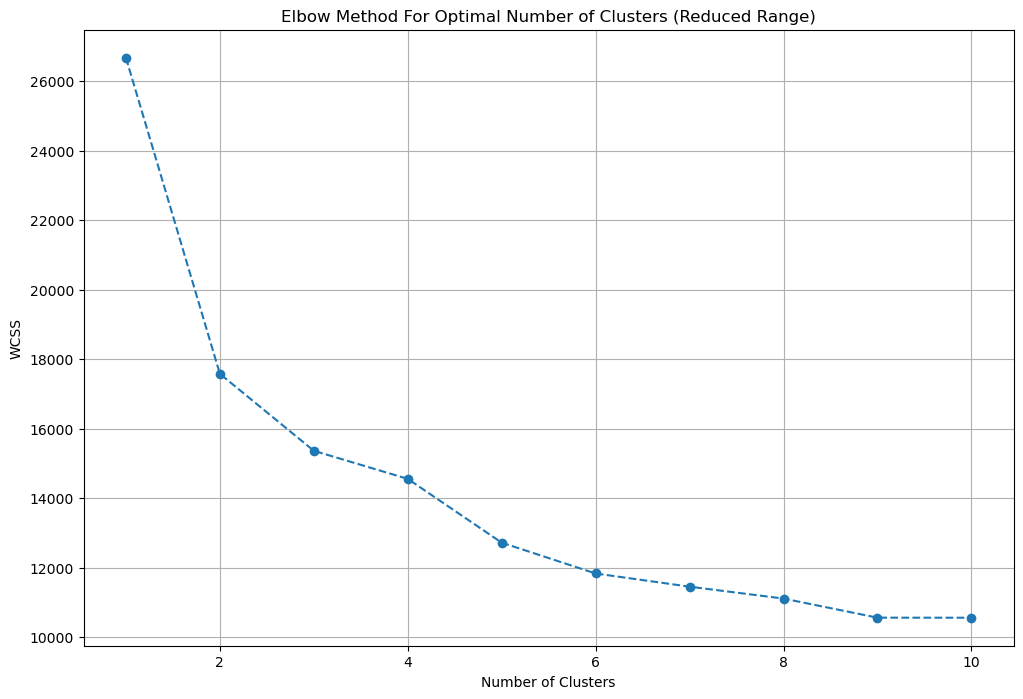

In [67]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [69]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [70]:
df['luxury_score'] = luxury_score

In [71]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,pioneer park,sector 61,1.60,11594.0,1380.0,Carpet area: 1380 (128.21 sq.m.),2,2,2,servant room,21.0,NaN,Relatively New,"['Sector 55-56 Rapid Metro', 'Hong Kong Bazaar', 'Golf Course Ext Rd', 'Gurugram University', 'Pathways School Gurgaon', 'W Pratiksha Hospital', 'Indira Gandhi International Airport', 'Duke Horse Riding Club', 'DLF Golf and Country Club', 'AIPL Business Club', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park', 'PVR Drive In Theatre', 'Surajgarh Gurgaon']","['2 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",NaN,NaN,1380.00,0,1,0,0,0,0,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Spacious Interiors, Low Density Society, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center, Water softening plant]",105
1,flat,godrej nature plus,sector 33,1.15,11558.0,995.0,Carpet area: 92.44,2,2,2,na,15.0,NaN,Under Construction,"['Signature Global Infinity Mall Sohna', 'Badshahpur Sohna Rd Hwy', 'Gurjar Samrat Jaipal Khatana Marg', 'K. R. Mangalam University', 'Vidya Niketan Sr Sec School', 'Sanjivani Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']","['3 Fan', '1 Exhaust Fan', '5 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,92.44,0,0,0,0,0,0,"[Intercom Facility, Lift(s), Swimming Pool, Park, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",38
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.),5,5,3,na,2.0,NaN,Relatively New,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']","['5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Microwave', '7 Light', '5 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Club house / Community Center']",NaN,350.0,NaN,0,0,0,0,0,2,"[Private Garden / Terrace, Maintenance Staff, Water Storage, Club house / Community Center]",22
3,flat,bptp astaire gardens,sector 70a,1.60,8658.0,1848.0,Super Built up area 1848(171.68 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),4,4,3,"study room,others",1.0,NaN,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur S

In [72]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [73]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2197,flat,dlf the arbour,sector 63,7.80,19747.0,3950.0,Built Up area: 3950 (366.97 sq.m.),4,4,0,6.0,NaN,Undefined,NaN,3950.0,NaN,0,0,0,0,0,0,61
3358,flat,dlf the skycourt,sector 86,1.58,8190.0,1929.0,Super Built up area 1929(179.21 sq.m.)Built Up area: 1750 sq.ft. (162.58 sq.m.)Carpet area: 1450 sq.ft. (134.71 sq.m.),3,3,1,16.0,North,Relatively New,1929.0,1750.0,1450.0,0,0,0,1,0,2,152
2177,house,independent house sector 45,sector 40,9.00,38022.0,2367.0,Plot area 2367(219.9 sq.m.)Built Up area: 9000 sq.ft. (836.13 sq.m.)Carpet area: 6000 sq.ft. (557.42 sq.m.),12,12,3,4.0,North-West,New Property,NaN,9000.0,6000.0,0,1,0,0,0,2,71
1514,flat,shree vardhman victoria,sector 70,1.64,8384.0,1956.0,Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.),3,5,3,3.0,North,Relatively New,1950.0,NaN,1161.0,0,1,0,0,0,0,51
1259,flat,NaN,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,NaN,NaN,Under Construction,NaN,1625.0,NaN,0,0,0,0,0,0,0


In [74]:
df.to_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_feature_updated.csv',index=False)